In [2]:
#imports
import time
import pandas as pd

!pip install imbalanced-learn
import imblearn
from imblearn.over_sampling import RandomOverSampler

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler

In [3]:
import os
os.getcwd()

'C:\\Users\\chels\\Downloads'

In [17]:
#preprocessing
df= pd.read_csv(r"C:\Users\chels\Desktop\creditcard.csv")
df.head(5)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [6]:
#legit and fraud transactions
df['Class'].value_counts()
df.groupby('Class').mean()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
Class,,,,,,,,,,,,,,,,,,,,,
0,94838.202258,0.008258,-0.006271,0.012171,-0.007860,0.005453,0.002419,0.009637,-0.000987,0.004467,...,-0.000644,-0.001235,-0.000024,0.000070,0.000182,-0.000072,-0.000089,-0.000295,-0.000131,88.291022
1,80746.806911,-4.771948,3.623778,-7.033281,4.542029,-3.151225,-1.397737,-5.568731,0.570636,-2.581123,...,0.372319,0.713588,0.014049,-0.040308,-0.105130,0.041449,0.051648,0.170575,0.075667,122.211321


In [18]:
# seperate data for analysis
legit=df[df.Class==0]
fraud=df[df.Class==1]

In [19]:
print(legit.shape)
print(fraud.shape)

(284315, 31)
(492, 31)


In [20]:
#solving the unblanced data using 492 datapoints

legit_data=legit.sample(n=492)


In [21]:
#concatinating datasets

df2=pd.concat([legit_data,fraud], axis=0)

In [22]:
df2.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
279863,169142.0,-1.927883,1.125653,-4.518331,1.749293,-1.566487,-2.010494,-0.882850,0.697211,-2.064945,...,0.778584,-0.319189,0.639419,-0.294885,0.537503,0.788395,0.292680,0.147968,390.00,1
280143,169347.0,1.378559,1.289381,-5.004247,1.411850,0.442581,-1.326536,-1.413170,0.248525,-1.127396,...,0.370612,0.028234,-0.145640,-0.081049,0.521875,0.739467,0.389152,0.186637,0.76,1
280149,169351.0,-0.676143,1.126366,-2.213700,0.468308,-1.120541,-0.003346,-2.234739,1.210158,-0.652250,...,0.751826,0.834108,0.190944,0.032070,-0.739695,0.471111,0.385107,0.194361,77.89,1
281144,169966.0,-3.113832,0.585864,-5.399730,1.817092,-0.840618,-2.943548,-2.208002,1.058733,-1.632333,...,0.583276,-0.269209,-0.456108,-0.183659,-0.328168,0.606116,0.884876,-0.253700,245.00,1
281674,170348.0,1.991976,0.158476,-2.583441,0.408670,1.151147,-0.096695,0.223050,-0.068384,0.577829,...,-0.164350,-0.295135,-0.072173,-0.450261,0.313267,-0.289617,0.002988,-0.015309,42.53,1


In [23]:
df2['Class'].value_counts()

0    492
1    492
Name: Class, dtype: int64

In [24]:
df2.groupby('Class').mean()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
Class,,,,,,,,,,,,,,,,,,,,,
0,97337.365854,-0.074930,0.052032,0.064985,0.051232,0.079148,0.061886,0.091738,-0.036029,0.029882,...,-0.003066,-0.022272,-0.050280,0.042182,-0.001181,-0.009849,-0.023085,-0.006113,-0.011204,86.427846
1,80746.806911,-4.771948,3.623778,-7.033281,4.542029,-3.151225,-1.397737,-5.568731,0.570636,-2.581123,...,0.372319,0.713588,0.014049,-0.040308,-0.105130,0.041449,0.051648,0.170575,0.075667,122.211321


In [25]:
#splitting data 
X=df2.drop(columns='Class',axis=1)
Y=df2['Class']

In [26]:
X.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
36584,38602.0,1.179815,-0.901349,0.442071,0.204241,-0.516080,1.540580,-1.153088,0.509091,-0.315575,...,-0.456471,-0.396536,-0.742704,-0.150395,-1.785482,0.326831,-0.279644,0.081010,0.020925,74.00
146441,87704.0,1.943090,0.533183,-2.179182,1.580856,0.909674,-1.130860,0.810380,-0.439684,-0.101085,...,-0.089184,0.019566,0.253047,0.010451,1.000713,0.464266,-0.552768,0.001755,-0.010059,39.82
77386,57026.0,-0.971299,1.127940,2.314688,2.270630,0.397830,-0.121950,0.511413,0.109500,-1.447482,...,-0.007449,-0.119219,-0.528341,-0.006917,0.337670,-0.050398,-0.134189,-0.091699,0.133547,7.51
229329,145882.0,0.072574,0.476347,-0.238630,-0.580035,0.992914,-0.759767,0.712880,-0.055714,0.176640,...,-0.006196,-0.189791,-0.427885,0.191754,0.597313,-0.671361,0.138378,0.255304,0.114408,1.00
45084,42202.0,0.681155,-0.651906,1.220721,3.039086,-0.946769,0.900976,-0.504932,0.362438,0.623665,...,0.108134,0.155583,0.327079,-0.260894,0.105630,0.427985,0.225446,0.018991,0.055829,200.97


In [27]:

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split 
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,stratify=Y,random_state=42)

In [28]:
 print(X.shape,X_train.shape,X_test.shape)

(984, 30) (787, 30) (197, 30)


Classification Report :
               precision    recall  f1-score   support

       fraud       0.95      0.93      0.94        99
       legit       0.93      0.95      0.94        98

    accuracy                           0.94       197
   macro avg       0.94      0.94      0.94       197
weighted avg       0.94      0.94      0.94       197

accuracy=  0.9390862944162437


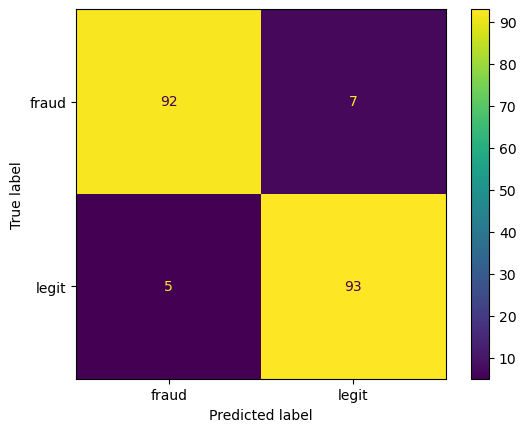

In [29]:
#logisitic regress
import matplotlib.pyplot as plt
lr= LogisticRegression(solver='lbfgs', max_iter=1000)
lr.fit(X_train,Y_train)
pred = lr.predict(X_test)

b_type = ["fraud","legit"]

results = classification_report(Y_test, pred, target_names= b_type)
print('Classification Report :\n',results)

matrix = confusion_matrix(Y_test,pred)
print('accuracy= ', accuracy_score(Y_test, pred))
display = ConfusionMatrixDisplay(matrix, display_labels= b_type)
display.plot()
plt.show()

Classification Report :
               precision    recall  f1-score   support

       fraud       0.87      1.00      0.93        99
       legit       1.00      0.85      0.92        98

    accuracy                           0.92       197
   macro avg       0.93      0.92      0.92       197
weighted avg       0.93      0.92      0.92       197

accuracy=  0.9238578680203046


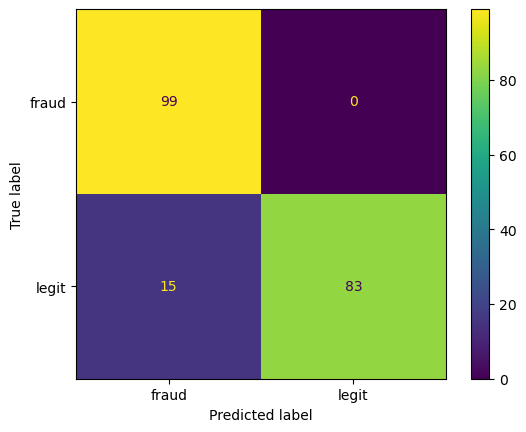

In [30]:
from sklearn.svm import SVC

svm = SVC(gamma = 'auto', kernel = 'linear', decision_function_shape='ovo')
svm.fit(X_train,Y_train)
pred = svm.predict(X_test)

b_type = ["fraud","legit"]

results = classification_report(Y_test, pred, target_names= b_type)
print('Classification Report :\n',results)

matrix = confusion_matrix(Y_test,pred)
print('accuracy= ', accuracy_score(Y_test, pred))
display = ConfusionMatrixDisplay(matrix, display_labels= b_type)
display.plot()
plt.show()

     ---------------------------------------- 70.9/70.9 MB 7.1 MB/s eta 0:00:00
Classification Report :
               precision    recall  f1-score   support

       fraud       0.95      0.90      0.92        99
       legit       0.90      0.95      0.93        98

    accuracy                           0.92       197
   macro avg       0.92      0.92      0.92       197
weighted avg       0.92      0.92      0.92       197

accuracy=  0.9238578680203046


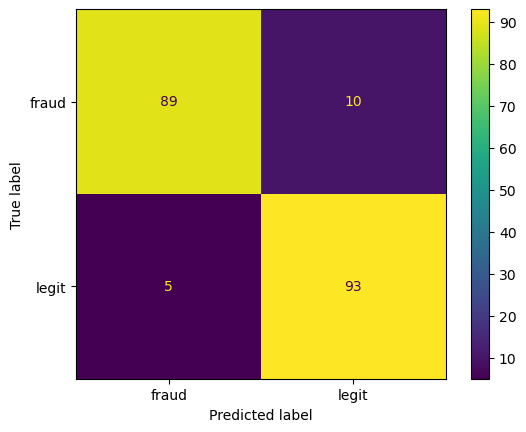

In [31]:
!pip install xgboost
import xgboost as xgb
xg = xgb.XGBClassifier(objective= 'binary:logistic', n_estimators = 10, seed= 123)

xg.fit(X_train,Y_train)
pred= xg.predict(X_test)

b_type = ["fraud","legit"]

results = classification_report(Y_test, pred, target_names= b_type)
print('Classification Report :\n',results)

matrix = confusion_matrix(Y_test,pred)
print('accuracy= ', accuracy_score(Y_test, pred))
display = ConfusionMatrixDisplay(matrix, display_labels= b_type)
display.plot()
plt.show()

In [32]:
from sklearn.ensemble import StackingClassifier

Classification Report :
               precision    recall  f1-score   support

       fraud       0.95      0.96      0.95        99
       legit       0.96      0.95      0.95        98

    accuracy                           0.95       197
   macro avg       0.95      0.95      0.95       197
weighted avg       0.95      0.95      0.95       197

accuracy=  0.9543147208121827


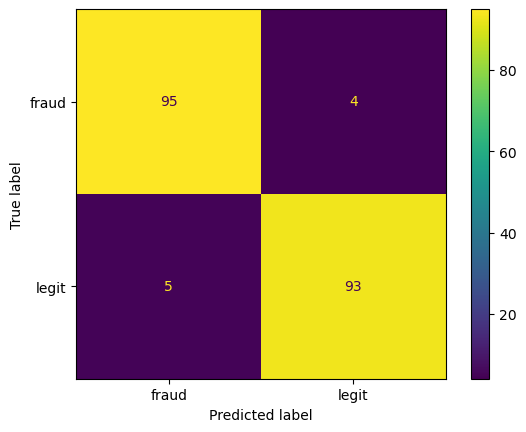

In [33]:
from sklearn.ensemble import StackingClassifier
estimators= [('svm', svm), ('logreg', lr)]
 
stack = StackingClassifier(estimators=estimators, final_estimator=xg)
stack.fit(X_train,Y_train)

pred= stack.predict(X_test)

b_type = ["fraud","legit"]

results = classification_report(Y_test, pred, target_names= b_type)
print('Classification Report :\n',results)

matrix = confusion_matrix(Y_test,pred)
print('accuracy= ', accuracy_score(Y_test, pred))
display = ConfusionMatrixDisplay(matrix, display_labels= b_type)
display.plot()
plt.show()

In [34]:
pip install flask

In [ ]:
from flask import Flask
app= Flask(___name____)
def

In [35]:
!pip install streamlit

     ---------------------------------------- 8.9/8.9 MB 15.3 MB/s eta 0:00:00
     ------------------------------------- 184.3/184.3 kB 10.9 MB/s eta 0:00:00
     ---------------------------------------- 4.8/4.8 MB 17.0 MB/s eta 0:00:00
     ------------------------------------- 813.6/813.6 kB 17.1 MB/s eta 0:00:00
     ------------------------------------- 904.0/904.0 kB 14.4 MB/s eta 0:00:00
     -------------------------------------- 238.7/238.7 kB 7.4 MB/s eta 0:00:00
     -------------------------------------- 164.8/164.8 kB 5.0 MB/s eta 0:00:00
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
     --------------------------------------- 21.5/21.5 MB 11.3 MB/s eta 0:00:00
     ---------------------------------------- 62.7/62.7 kB 3.3 MB/s eta 0:00:00
     ---------------------------------------- 1.1/1.1 MB 14.6 MB/s eta 0:00:00
     ---------------------------------------- 84.5/84.5 kB 4.9 MB/s eta 0:00:00
     ----------------

In [ ]:
import streamlit as st
st.set_page_config(page_title='fraud detector')
st.title('fraud detector')
st.write('enter transactions data for testing')